# 04 · Batch run, climatological footprint & geospatial export

Run a footprint for every record in a day-long table with `run_batch`, average the
periods into a **climatological footprint**, then export a georeferenced GeoTIFF
and 50/80/90 % contour polygons (a shapefile) and overlay them with `geopandas`.

> Requires the geospatial extra: `pip install "lagranged[geo]"`.
>
> The per-period densities live in the **upwind model frame**, so we hold
> `wind_dir` fixed and vary stability/`u*` across the day. Aggregating a climatology
> over *varying* wind directions instead requires accumulating in the geographic
> frame — see [`docs/limitations.md`](../docs/limitations.md).

In [1]:
%matplotlib inline
import tempfile
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import lagranged as lg

warnings.filterwarnings("ignore", message="No measured TowerTurbulence")

## A day of synthetic records

Columns map directly onto `FootprintInputs` fields, so `run_batch` can build inputs
per row. The grid carries `origin_xy` (the tower easting/northing) and `crs` so the
exports are georeferenced.

In [2]:
rng = np.random.default_rng(0)
n = 8
day = pd.DataFrame(
    {
        "zm": np.full(n, 3.0),
        "z0": np.full(n, 0.03),
        "d": np.full(n, 0.2),
        # A mix of near-neutral and convective half-hours over the day.
        "L": np.concatenate([np.full(4, -10_000.0), np.full(4, -60.0)]),
        "ustar": 0.28 + 0.08 * rng.random(n),
        "umean": np.full(n, 2.4),
        "wind_dir": np.full(n, 210.0),   # held fixed: aggregate in the model frame
        "h": np.full(n, 1000.0),
        "sigma_v": np.full(n, 0.6),
    }
)

grid = lg.DomainGrid(
    nx=60, ny=60, dx=4.0, dy=4.0, x0=-80.0, y0=-120.0,
    origin_xy=(500_000.0, 4_500_000.0),  # tower easting/northing
    crs="EPSG:32612",
)
config = lg.ModelConfig(n_particles=300, dt_factor=0.05, t_max=90.0,
                        rebound_height=0.5, seed=0)

results = lg.run_batch(day, grid=grid, config=config)
print(f"{len(results)} periods ran successfully")

8 periods ran successfully


## Climatological footprint

Each period's density integrates to 1; averaging them (and re-normalizing) yields a
climatological footprint that also integrates to 1. We wrap it in a
`FootprintResult` so the plotting and export helpers apply unchanged.

climatological integral = 1.000000


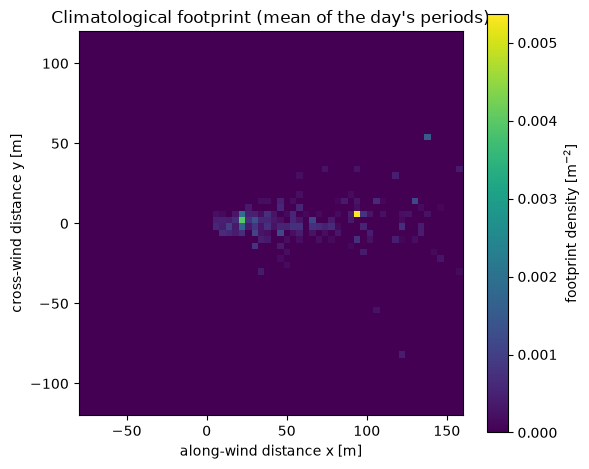

In [3]:
stack = np.stack([r.density for r in results.values()])
clim_density = stack.mean(axis=0)
clim_density /= clim_density.sum() * grid.dx * grid.dy  # renormalize to ∫=1

example = next(iter(results.values()))
clim = lg.FootprintResult(
    density=clim_density, x=example.x, y=example.y, inputs=example.inputs
)
print(f"climatological integral = {clim.density.sum() * grid.dx * grid.dy:.6f}")

fig, ax = plt.subplots(figsize=(6, 5))
lg.plot_footprint(clim, ax=ax)
lg.plot_contours(clim, ax=ax, colors="white", linewidths=0.8)
ax.set_title("Climatological footprint (mean of the day's periods)")
fig.tight_layout()
plt.show()

## Export: GeoTIFF + contour shapefile

`to_geotiff` writes the density as a georeferenced raster (the wind-direction
rotation is baked losslessly into the affine geotransform — no resampling).
`contour_gdf` returns the 50/80/90 % source-area polygons as a `GeoDataFrame` in the
grid CRS, which we save as a shapefile. We write to a temporary directory so CI
leaves no artifacts behind.

In [4]:
outdir = Path(tempfile.mkdtemp(prefix="lagranged_"))
tif_path = outdir / "climatological_footprint.tif"
shp_path = outdir / "footprint_contours.shp"

clim.to_geotiff(str(tif_path), grid)
gdf = clim.contour_gdf(grid)
gdf = gdf.dropna(subset=["geometry"])
gdf.to_file(str(shp_path))

print("GeoTIFF :", tif_path, "->", tif_path.exists())
print("Shapefile:", shp_path, "->", shp_path.exists())
gdf[["fraction", "level"]]

GeoTIFF : C:\Users\PAULIN~1\AppData\Local\Temp\1\lagranged_t91eq5na\climatological_footprint.tif -> True
Shapefile: C:\Users\PAULIN~1\AppData\Local\Temp\1\lagranged_t91eq5na\footprint_contours.shp -> True


,fraction,level
0,0.5,0.000657
1,0.8,0.000357
2,0.9,0.000239


## Overlay the contours with geopandas

The polygons are in projected coordinates (`EPSG:32612`), so they plot in real
metres around the tower. Add a basemap with `contextily` if you need aerial imagery
underneath (an optional dependency, omitted here so the notebook needs no network).

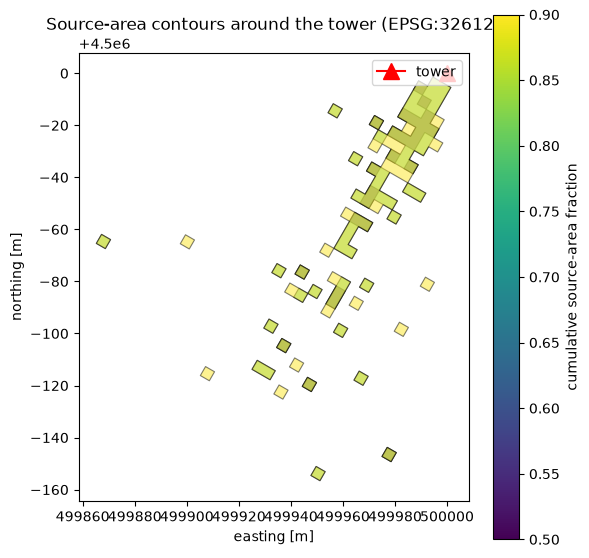

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
gdf.plot(
    ax=ax, column="fraction", cmap="viridis", alpha=0.5,
    edgecolor="black", linewidth=0.8, legend=True,
    legend_kwds={"label": "cumulative source-area fraction"},
)
ex, ny_ = grid.origin_xy
ax.plot(ex, ny_, marker="^", color="red", markersize=12, label="tower")
ax.set_xlabel("easting [m]")
ax.set_ylabel("northing [m]")
ax.set_aspect("equal")
ax.set_title("Source-area contours around the tower (EPSG:32612)")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()